# Зачет по МФК «Математическая статистика и анализ данных»

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

## Пункт 0. Подготовка данных

Загрузка данных. Удаление всех строк, где есть пропущенные значения. + подсчёт скорости в милях в час

In [8]:
flights_raw = pd.read_csv("flights_NY.csv")
flights = flights_raw.dropna().copy()
flights["speed"] = flights["distance"] / flights["air_time"] * 60

pd.DataFrame({
    "Label": ["Изначально строк", "Строк после чистки", "difference"],
    "Value": [len(flights_raw), len(flights), len(flights_raw) - len(flights)],
})

,Label,Value
0,Изначально строк,336776
1,Строк после чистки,327346
2,difference,9430


In [9]:
flights.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,speed
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,370.044053
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,374.273128
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,408.375000
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,516.721311
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,394.137931


## Пункт 1. Вероятность задержки вылета

Выберите авиакомпании, которые для перелетов из Нью-Йорка использовали более 200 различных самолетов, и для каждой из них оцените вероятность задержки вылета. Результаты изобразите на графике, отсортировав авиакомпании по убыванию числа самолетов. Для какой авиакомпании вероятность окажется наибольшей?

In [11]:
carrier_stats = (
    flights.groupby("carrier")
    .agg(
        n_planes=("tailnum", "nunique"),
        n_flights=("flight", "size"),
        dep_delay_probability=("dep_delay", lambda x: (x > 0).mean()),
    )
    .query("n_planes > 200")
    .sort_values("n_planes", ascending=False)
)
carrier_stats.round(4)

,n_planes,n_flights,dep_delay_probability
carrier,,,
DL,626,47658,0.3186
UA,620,57782,0.4694
AA,600,31947,0.3163
WN,581,12044,0.5426
EV,316,51108,0.4496
US,289,19831,0.2401
MQ,237,25037,0.3182
9E,203,17294,0.4036


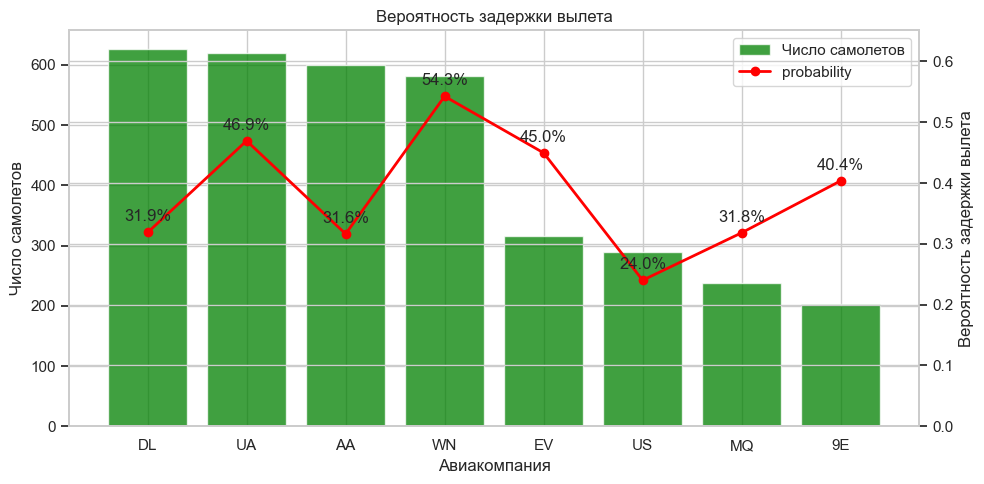

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(carrier_stats))

ax1.bar(x, carrier_stats["n_planes"], color="green", alpha=0.75, label="Число самолетов")
ax1.set_xticks(x)
ax1.set_xticklabels(carrier_stats.index)
ax1.set_xlabel("Авиакомпания")
ax1.set_ylabel("Число самолетов")
ax1.set_title("Вероятность задержки вылета")

ax2 = ax1.twinx()
ax2.plot(x, carrier_stats["dep_delay_probability"], color="red", marker="o", linewidth=2, label="probability")
ax2.set_ylabel("Вероятность задержки вылета")
ax2.set_ylim(0, carrier_stats["dep_delay_probability"].max() * 1.2)

for i, p in enumerate(carrier_stats["dep_delay_probability"]):
    ax2.annotate(f"{p:.1%}", (x[i], p), textcoords="offset points", xytext=(0, 8), ha="center")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
plt.tight_layout()
plt.show()

In [21]:
best_carrier = carrier_stats["dep_delay_probability"].idxmax()
best_probability = carrier_stats.loc[best_carrier, "dep_delay_probability"]
print(f"Наибольшая вероятность задержки вылета: {best_carrier}, {best_probability:.2%}")

Наибольшая вероятность задержки вылета: WN, 54.26%


Вывод: максимальная вероятность задержки вылета среди выбранных компаний у WN: около 54.26%. При этом компании делятся на 2 кластера - (DL, UA, AA, WN) и (EV, US, MQ, 9E), где компании из первого кластера имеют более 550 самолётов в своём авиапарке, а из второго кластера компании имеют число самолётов менее 350.

## Пункт 2. Среднее время в воздухе по самолетам

Для каждого самолета найдите среднее время, которое он проводит в воздухе, и постройте гистограмму на основе полученных значений. Предполагая, что это распределение описывается нормальным законом, оцените параметры нормального закона и наложите график плотности полученного нормального закона на график с гистограммой. В каких пределах лежит среднее время для 95% всех самолетов?

In [28]:
plane_air_time = flights.groupby("tailnum")["air_time"].mean()
mu_air = plane_air_time.mean()
sigma_air = plane_air_time.std(ddof=1)
bounds_95 = stats.norm.interval(0.95, loc=mu_air, scale=sigma_air)

pd.Series({
    "Число самолетов": plane_air_time.size,
    "mu, минут": mu_air,
    "sigma, минут": sigma_air,
    "Левая граница (95%)": bounds_95[0],
    "Правая граница (95%)": bounds_95[1],
}).round(3)

Число самолетов         4037.000
mu, минут                157.497
sigma, минут              75.805
Левая граница (95%)        8.922
Правая граница (95%)     306.072
dtype: float64

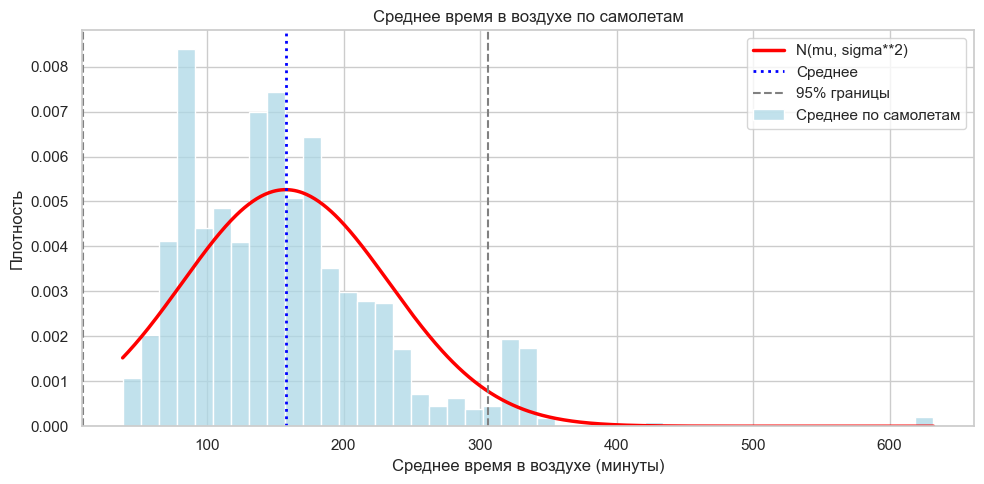

In [50]:
x_grid = np.linspace(plane_air_time.min(), plane_air_time.max(), 600)
y_grid = stats.norm.pdf(x_grid, loc=mu_air, scale=sigma_air)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(plane_air_time, bins=45, stat="density", color="lightblue", ax=ax, label="Среднее по самолетам")
ax.plot(x_grid, y_grid, color="red", linewidth=2.5, label=f"N(mu, sigma**2)")
ax.axvline(mu_air, color="blue", linestyle=":", linewidth=2, label="Среднее")
ax.axvline(bounds_95[0], color="gray", linestyle="--", linewidth=1.5, label="95% границы")
ax.axvline(bounds_95[1], color="gray", linestyle="--", linewidth=1.5)
ax.set_title("Среднее время в воздухе по самолетам")
ax.set_xlabel("Среднее время в воздухе (минуты)")
ax.set_ylabel("Плотность")
ax.legend()
plt.tight_layout()
plt.show()

Вывод: mu = 157.50 минут, sigma = 75.80 минут. По 95% значений лежат примерно от 8.92 до 306.07 минут. Есть всплеск за 600 минутами

## Пункт 3. Сравнение WN и UA по средней скорости

Значимо ли различаются распределения средней скорости самолетов между авиакомпаниями WN и UА? Подтвердите вывод статистическим тестом. Нарисуйте графики распределений, отметьте на них средние значение и доверительный интервал с уровнем доверия 0.95 для среднего.
Средние сравниваются t-тестом Уэлча, распределения целиком — критерием Колмогорова-Смирнова.

In [51]:
carrier_plane_speed = (
    flights[flights["carrier"].isin(["WN", "UA"])]
    .groupby(["carrier", "tailnum"])
    .agg(mean_speed=("speed", "mean"), n_flights=("flight", "size"))
    .reset_index()
)

rows = []
for carrier, part in carrier_plane_speed.groupby("carrier"):
    x = part["mean_speed"]
    ci = stats.t.interval(0.95, df=len(x) - 1, loc=x.mean(), scale=stats.sem(x))
    rows.append({
        "carrier": carrier,
        "n_planes": len(x),
        "mean_speed_mph": x.mean(),
        "std_speed_mph": x.std(ddof=1),
        "95_left": ci[0],
        "95_right": ci[1],
    })

speed_summary = pd.DataFrame(rows).set_index("carrier")
speed_summary.round(3)

,n_planes,mean_speed_mph,std_speed_mph,95_left,95_right
carrier,,,,,
UA,620,423.366,18.189,421.932,424.801
WN,581,397.644,14.342,396.475,398.813


In [52]:
wn_speed = carrier_plane_speed.loc[carrier_plane_speed["carrier"] == "WN", "mean_speed"]
ua_speed = carrier_plane_speed.loc[carrier_plane_speed["carrier"] == "UA", "mean_speed"]

welch_test = stats.ttest_ind(wn_speed, ua_speed, equal_var=False)
ks_test = stats.ks_2samp(wn_speed, ua_speed)

pd.DataFrame({
    "Тест": ["t-тест Уэлча", "Колмогоров-Смирнов"],
    "Статистика": [welch_test.statistic, ks_test.statistic],
    "p-value": [welch_test.pvalue, ks_test.pvalue],
}).set_index("Тест")

,Статистика,p-value
Тест,,
t-тест Уэлча,-27.301769,2.792906e-127
Колмогоров-Смирнов,0.678674,4.126460e-132


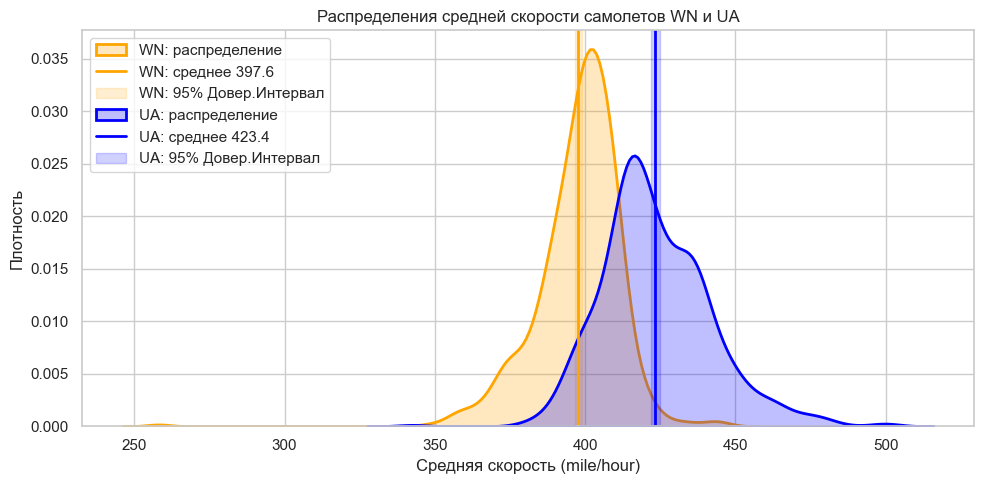

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"WN": "orange", "UA": "blue"}

for carrier in ["WN", "UA"]:
    x = carrier_plane_speed.loc[carrier_plane_speed["carrier"] == carrier, "mean_speed"]
    mean = x.mean()
    ci = stats.t.interval(0.95, df=len(x) - 1, loc=mean, scale=stats.sem(x))
    sns.kdeplot(x=x, fill=True, alpha=0.25, linewidth=2, color=colors[carrier], label=f"{carrier}: распределение", ax=ax)
    ax.axvline(mean, color=colors[carrier], linewidth=2, label=f"{carrier}: среднее {mean:.1f}")
    ax.axvspan(ci[0], ci[1], color=colors[carrier], alpha=0.18, label=f"{carrier}: 95% Довер.Интервал")

ax.set_title("Распределения средней скорости самолетов WN и UA")
ax.set_xlabel("Средняя скорость (mile/hour)")
ax.set_ylabel("Плотность")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Вывод: WN = 397.64 миль/ч, UA = 423.37 миль/ч. p-value обоих тестов намного меньше 0.05, значит распределения средней скорости WN и UA статистически значимо различаются.

## Пункт 4. Регрессия среднего расстояния на среднюю скорость

Используя модель линейной регрессии, найдите зависимость среднего расстояния, на которое летает самолет, от его средней скорости (при необходимости, используйте полиномиальные признаки и/или другие преобразования признаков). Постройте график, содержащий данные и полученную зависимость. Сравнение линейной и квадратичной регрессии.

In [46]:
planes = (
    flights.groupby("tailnum")
    .agg(
        mean_speed=("speed", "mean"),
        mean_distance=("distance", "mean"),
        n_flights=("flight", "size"),
    )
    .reset_index()
)

X_linear = sm.add_constant(planes[["mean_speed"]])
linear_model = sm.OLS(planes["mean_distance"], X_linear).fit()

X_quadratic = sm.add_constant(pd.DataFrame({
    "mean_speed": planes["mean_speed"],
    "mean_speed_sq": planes["mean_speed"] ** 2,
}))
quadratic_model = sm.OLS(planes["mean_distance"], X_quadratic).fit()

pd.DataFrame({
    "model": ["linear", "quadratic"],
    "R2 (higher better)": [linear_model.rsquared, quadratic_model.rsquared],
    "AIC (lower better)": [linear_model.aic, quadratic_model.aic],
}).set_index("model").round(3)

,R2 (higher better),AIC (lower better)
model,,
linear,0.625,59247.402
quadratic,0.745,57696.129


In [36]:
print(quadratic_model.summary())

                            OLS Regression Results                            
Dep. Variable:          mean_distance   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     5894.
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        21:46:36   Log-Likelihood:                -28845.
No. Observations:                4037   AIC:                         5.770e+04
Df Residuals:                    4034   BIC:                         5.772e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.117e+04    351.996     31.733

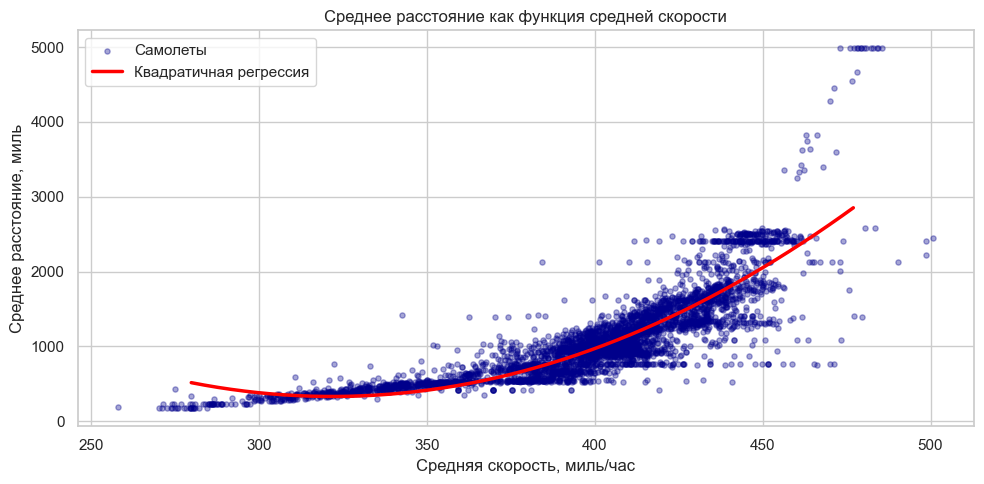

In [48]:
x_grid = np.linspace(planes["mean_speed"].quantile(0.005), planes["mean_speed"].quantile(0.995), 300)
X_grid = sm.add_constant(pd.DataFrame({"mean_speed": x_grid, "mean_speed_sq": x_grid ** 2}))
y_pred = quadratic_model.predict(X_grid)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(planes["mean_speed"], planes["mean_distance"], s=14, alpha=0.35, color="darkblue", label="Самолеты")
ax.plot(x_grid, y_pred, color="red", linewidth=2.5, label="Квадратичная регрессия")
ax.set_title("Среднее расстояние как функция средней скорости")
ax.set_xlabel("Средняя скорость, миль/час")
ax.set_ylabel("Среднее расстояние, миль")
ax.legend()
plt.tight_layout()
plt.show()

Вывод: квадратичная модель лучше линейной по R² и AIC: R² ≈ 0.745 против 0.625. Cамолеты с большей средней скоростью обычно летают на большие расстояния. (что на самом деле логично)

## 5. Кластеризация самолетов

Методом кластерного анализа разделите самолеты на группы на основе пары признаков: средняя скорость и число выполненных рейсов. Постройте точечную диаграмму на основе этих пар признаков и отметьте кластеры разными цветами. Можно ли предложить интерпретацию для образовавшихся кластеров (хотя бы для некоторых)?
Число кластеров выбираются по silhouette score для k от 2 до 6.

In [38]:
cluster_features = planes[["mean_speed", "n_flights"]]
Z = StandardScaler().fit_transform(cluster_features)

silhouette_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(Z)
    silhouette_rows.append({"k": k, "silhouette_score": silhouette_score(Z, labels)})

silhouette_table = pd.DataFrame(silhouette_rows).set_index("k")
silhouette_table.round(3)

,silhouette_score
k,
2,0.519
3,0.529
4,0.382
5,0.434
6,0.453


In [39]:
best_k = int(silhouette_table["silhouette_score"].idxmax())
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
planes["cluster"] = kmeans.fit_predict(Z)

cluster_summary = (
    planes.groupby("cluster")
    .agg(
        n_planes=("tailnum", "size"),
        mean_speed=("mean_speed", "mean"),
        median_speed=("mean_speed", "median"),
        mean_flights=("n_flights", "mean"),
        median_flights=("n_flights", "median"),
        mean_distance=("mean_distance", "mean"),
    )
    .sort_values("mean_flights")
)
cluster_summary.round(2)

,n_planes,mean_speed,median_speed,mean_flights,median_flights,mean_distance
cluster,,,,,,
0,2932,413.08,410.61,52.45,40.0,1248.89
2,519,328.05,328.79,54.31,42.0,422.80
1,586,388.25,385.59,248.10,247.0,927.72


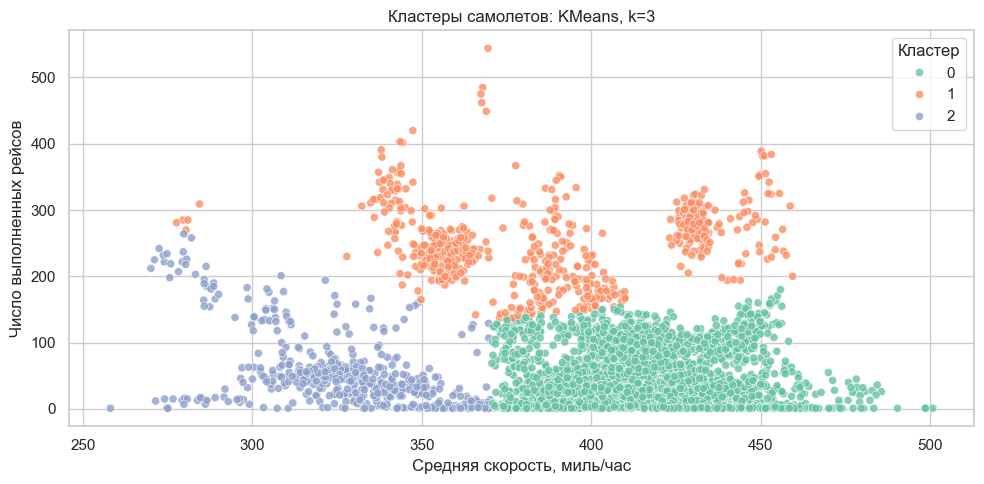

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=planes, x="mean_speed", y="n_flights", hue="cluster", palette="Set2", s=35, alpha=0.8, ax=ax)
ax.set_title(f"Кластеры самолетов: KMeans, k={best_k}")
ax.set_xlabel("Средняя скорость, миль/час")
ax.set_ylabel("Число выполненных рейсов")
ax.legend(title="Кластер")
plt.tight_layout()
plt.show()

Вывод: лучший silhouette score среди k=2..6 получился при k=3. Интерпретация кластеров: медленные самолеты коротких региональных маршрутов; основной парк со средней/высокой скоростью и умеренным числом рейсов; интенсивно используемые самолеты с большим числом рейсов.